In [26]:
#!pip3 install tensorflow

In [27]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

In [43]:
SEED = 123
tf.config.experimental.enable_op_determinism()
tf.random.set_seed(SEED)

In [11]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
X_train[2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  67, 232,  39,   0,   0,   0,
          0,   0],
       [  

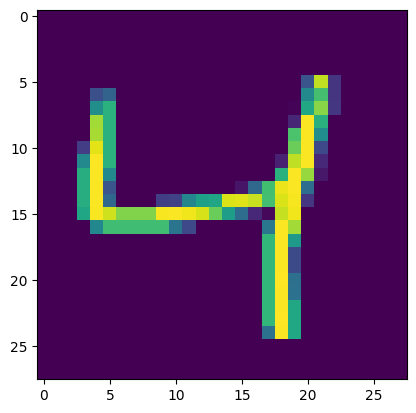

In [15]:
import matplotlib.pyplot as plt
plt.imshow(X_train[2])

In [20]:
X_train[2].shape

(28, 28)

In [16]:
y_train[2]

np.uint8(4)

In [19]:
# Normalise pixel values
X_train, X_test = X_train / 255.0, X_test / 255.0

In [44]:
# Building the neural network
model = Sequential()
model.add(Input(shape=(28, 28)))
model.add(Flatten())                        # 784 input nodes
model.add(Dense(128, activation="relu"))    # 128 hidden nodes
model.add(Dense(32, activation="relu"))     # 32 hidden nodes
model.add(Dense(11, activation="softmax"))  # 11 output nodes
    # Use softmax for multi-class classification
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,971 (410.04 KB)

 Trainable params: 104,971 (410.04 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Params include both weights and biases

In [45]:
model.compile(
    loss="sparse_categorical_crossentropy",  # The loss function
    optimizer="Adam",
        # Optimizer is a method to adjust the model's parameters to minimize the loss
    metrics=["accuracy"]
)
history = model.fit(
    X_train, y_train, epochs=25, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 798us/step - accuracy: 0.9191 - loss: 0.2850 - val_accuracy: 0.9575 - val_loss: 0.1471
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.9635 - loss: 0.1250 - val_accuracy: 0.9640 - val_loss: 0.1226
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 722us/step - accuracy: 0.9753 - loss: 0.0851 - val_accuracy: 0.9680 - val_loss: 0.1102
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.9827 - loss: 0.0611 - val_accuracy: 0.9701 - val_loss: 0.1044
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 721us/step - accuracy: 0.9876 - loss: 0.0457 - val_accuracy: 0.9702 - val_loss: 0.1005
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.9899 - loss: 0.0359 - val_accuracy: 0.9727 - val_loss: 0.1032
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 726us/step - accuracy: 0.9911 - loss: 0.0291 - val_accuracy: 0.9721 - val_loss: 0.1068
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step - accuracy: 0.9921 -

In [48]:
y_prob = model.predict(X_test)
y_pred = y_prob.argmax(axis=1)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step


0.9782

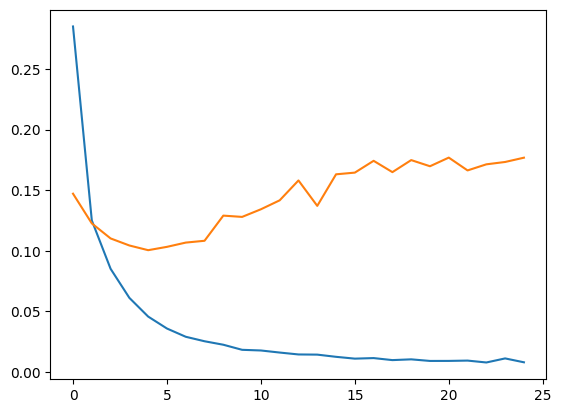

In [49]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

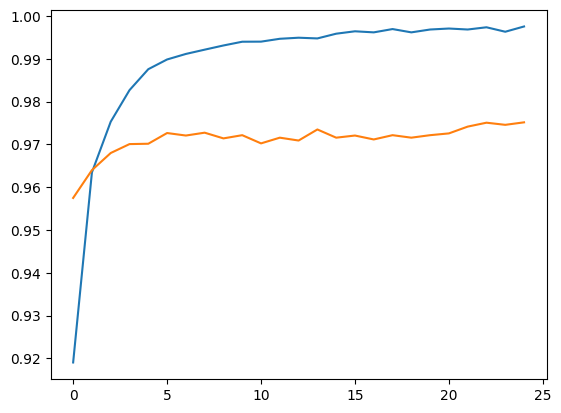

In [50]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])